In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import tensorflow as tf
print(tf.config.list_physical_devices())


[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import f1_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D, Dense, Dropout, Input, ReLU, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

In [ ]:
#Load dataset
df = pd.read_csv('clean_df.csv')  # Ensure this file path is correct

# Step 1: Combine specified classes into 'Unknown'
unknown_classes = [
     'Web Attack – Brute Force', 'Web Attack – XSS',
    'Infiltration', 'Web Attack – SQL Injection', 'Heartbleed'
]
df[' Label'] = df[' Label'].apply(lambda x: 'Unknown' if x in unknown_classes else x)

# Verify and filter dataset size
print(f"Initial dataset shape: {df.shape}")
print(f"Label counts:\n{df[' Label'].value_counts()}")

# Define sample sizes
expected_counts = {
    'BENIGN': 5499,
    'Unknown': 2227,  # Bot (1,966) + Brute Force (1,507) + XSS (652) + Infiltration (36) + SQL Injection (21) + Heartbleed (11)
    'DoS Hulk': 5499,
    'PortScan': 5499,
    'DDoS': 5499,
    'DoS GoldenEye': 5499,
    'FTP-Patator': 5499,
    'SSH-Patator':5499,
    'DoS slowloris': 5499,
    'DoS Slowhttptest': 5499,
     'Bot': 1966

}
filtered_df = pd.DataFrame()
for label, count in expected_counts.items():
    if label in df[' Label'].values:
        label_data = df[df[' Label'] == label].sample(n=count, random_state=42, replace=False if count <= len(df[df[' Label'] == label]) else True)
        filtered_df = pd.concat([filtered_df, label_data], axis=0)
df = filtered_df.reset_index(drop=True)
print(f"Filtered dataset shape: {df.shape}")
print(f"Filtered label counts:\n{df[' Label'].value_counts()}")

Initial dataset shape: (2830743, 79)
Label counts:
 Label
BENIGN              2273097
DoS Hulk             231073
PortScan             158930
DDoS                 128027
DoS GoldenEye         10293
FTP-Patator            7938
SSH-Patator            5897
DoS slowloris          5796
DoS Slowhttptest       5499
Unknown                2227
Bot                    1966
Name: count, dtype: int64
Filtered dataset shape: (53684, 79)
Filtered label counts:
 Label
BENIGN              5499
DoS Hulk            5499
PortScan            5499
DDoS                5499
DoS GoldenEye       5499
FTP-Patator         5499
SSH-Patator         5499
DoS slowloris       5499
DoS Slowhttptest    5499
Unknown             2227
Bot                 1966
Name: count, dtype: int64


In [ ]:
print(df.columns)

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [ ]:
df.rename(columns={' Label': 'Label'}, inplace=True)


In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
#CNN Part

In [ ]:
# Step 2: Separate known and unknown samples
known_df = df[df['Label'] != 'Unknown'].copy()
unknown_df = df[df['Label'] == 'Unknown'].copy()
print(f"Known samples: {known_df.shape[0]}")
print(f"Unknown samples: {unknown_df.shape[0]}")

Known samples: 51457
Unknown samples: 2227


In [ ]:
# Step 3: Basic Preprocessing
# Handle NaN/infinity for both known and unknown
# Fit on known data only
known_df.replace([np.inf, -np.inf], np.nan, inplace=True)
unknown_df.replace([np.inf, -np.inf], np.nan, inplace=True)

for col in known_df.columns:
    if col != 'Label' and col != 'label_encoded':
        if known_df[col].isna().sum() > 0:
            mean_value = known_df[col].mean()  # Compute mean on known data only
            known_df[col].fillna(mean_value, inplace=True)
            unknown_df[col].fillna(mean_value, inplace=True)  # Apply to unknown data
            print(f"Filled NaN in column '{col}' with mean {mean_value:.4f} (computed from known data)")

print(f"After handling NaN (Known): {known_df.shape[0]} samples, NaN count: {known_df.isna().sum().sum()}")
print(f"After handling NaN (Unknown): {unknown_df.shape[0]} samples, NaN count: {unknown_df.isna().sum().sum()}")

# Verify 'Label' column
if 'Label' not in known_df.columns or 'Label' not in unknown_df.columns:
    raise ValueError(f"Column 'Label' not found. Available (Known): {known_df.columns.tolist()}, (Unknown): {unknown_df.columns.tolist()}")

Filled NaN in column 'Flow Bytes/s' with mean 2596798.0962 (computed from known data)
Filled NaN in column 'Flow Packets/s' with mean 53206.0039 (computed from known data)
After handling NaN (Known): 51457 samples, NaN count: 0
After handling NaN (Unknown): 2227 samples, NaN count: 0


/tmp/ipykernel_2746920/530685089.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  known_df[col].fillna(mean_value, inplace=True)
/tmp/ipykernel_2746920/530685089.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [ ]:
# Step 4: Remove zero-variance columns (fit on known data only)
# Fitting on known data ensures 'Unknown' data doesn't influence feature selection
X_known = known_df.drop(['Label', 'label_encoded'], axis=1, errors='ignore')
print(f"Initial features (Known): {X_known.shape[1]} columns: {X_known.columns.tolist()}")
selector = VarianceThreshold(threshold=0)
X_known_selected = selector.fit_transform(X_known)
selected_columns = X_known.columns[selector.get_support()].tolist()
print(f"Columns after zero-variance filter: {len(selected_columns)} columns: {selected_columns}")

# Apply the same columns to unknown data
X_unknown = unknown_df.drop(['Label', 'label_encoded'], axis=1, errors='ignore')[selected_columns]

# Drop non-informative columns
non_informative_cols = ['Fwd URG Flags', 'Fwd Header Length.1']
non_informative_cols = [col for col in non_informative_cols if col in selected_columns]
if non_informative_cols:
    selected_columns = [col for col in selected_columns if col not in non_informative_cols]
    print(f"Dropped non-informative columns: {non_informative_cols}")

# Update X_known and X_unknown
X_known = X_known[selected_columns]
X_unknown = X_unknown[selected_columns]
print(f"Final selected columns: {len(selected_columns)} columns: {selected_columns}")

Initial features (Known): 78 columns: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Cou

In [ ]:
# Step 5: Normalize features (fit on known data only, apply to both)
# Fitting on known data ensures 'Unknown' data remains out-of-distribution
skewed_cols = ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd IAT Total',
               'Bwd IAT Total', 'Fwd Packets/s', 'Bwd Packets/s', 'Fwd IAT Max',
               'Bwd IAT Max', 'Max Packet Length']
skewed_cols = [col for col in skewed_cols if col in X_known.columns]
if skewed_cols:
    min_max_scaler = MinMaxScaler()
    X_known[skewed_cols] = min_max_scaler.fit_transform(X_known[skewed_cols])  # Fit on known
    X_unknown[skewed_cols] = min_max_scaler.transform(X_unknown[skewed_cols])  # Apply to unknown
    print(f"Applied MinMaxScaler to: {skewed_cols}")

standard_cols = [col for col in X_known.columns if col not in skewed_cols]
if standard_cols:
    standard_scaler = StandardScaler()
    X_known[standard_cols] = standard_scaler.fit_transform(X_known[standard_cols])  # Fit on known
    X_unknown[standard_cols] = standard_scaler.transform(X_unknown[standard_cols])  # Apply to unknown
    print(f"Applied StandardScaler to: {standard_cols}")

# Clip outliers (fit on known data only, apply to both)
# Ensures 'Unknown' data doesn't influence clipping bounds
for col in X_known.columns:
    lower, upper = X_known[col].quantile([0.01, 0.99])
    X_known[col] = X_known[col].clip(lower=lower, upper=upper)
    X_unknown[col] = X_unknown[col].clip(lower=lower, upper=upper)
    print(f"Clipped column '{col}' to [{lower:.4f}, {upper:.4f}] (computed from known data)")


Applied MinMaxScaler to: ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd IAT Total', 'Bwd IAT Total', 'Fwd Packets/s', 'Bwd Packets/s', 'Fwd IAT Max', 'Bwd IAT Max', 'Max Packet Length']
Applied StandardScaler to: ['Destination Port', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Min', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Header Length', 'Bwd Header Length', 'Min Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Cou

In [ ]:
# Step 6: Reorder labels (define all classes upfront)
all_labels = ['BENIGN', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest',
              'DoS slowloris', 'FTP-Patator', 'PortScan', 'SSH-Patator' ,'Bot','Unknown']
le = LabelEncoder()
le.classes_ = np.array(all_labels)  # Set all classes explicitly

# Encode labels
known_df['label_encoded'] = le.transform(known_df['Label'])
unknown_df['label_encoded'] = le.transform(unknown_df['Label'])

In [ ]:
# Step 1: Split known data into train/test
X_train, X_test_known, y_train, y_test_known = train_test_split(
    X_known,
    known_df['label_encoded'],
    test_size=0.2,
    stratify=known_df['label_encoded'],
    random_state=42
)

# Step 2: Combine known and unknown test data
X_test = pd.concat([X_test_known, X_unknown], axis=0)
y_test = pd.concat([
    pd.Series(y_test_known, index=X_test_known.index),
    pd.Series(unknown_df['label_encoded'], index=X_unknown.index)
], axis=0)

# Step 3: Ensure labels are 1D arrays
y_train = np.squeeze(y_train.values)
y_test = np.squeeze(y_test.values)

# Step 4: One-hot encoding
num_classes_train = len(np.unique(y_train))   # Only known classes
num_classes_total = len(le.classes_)          # All classes (including 'Unknown')

y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=num_classes_train)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=num_classes_total)

# Step 5: Print info
print(f"Training set size: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test set size (Known): {X_test_known.shape[0]} samples")
print(f"Test set size (Unknown): {X_unknown.shape[0]} samples")
print(f"Test set size (Total): {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"y_train_cat shape: {y_train_cat.shape}")
print(f"y_test_cat shape: {y_test_cat.shape}")

# Step 6: Optional check for data leakage
train_set = set(X_train.index)
test_set = set(X_test.index)
overlap = train_set.intersection(test_set)
print(f"Number of overlapping samples between train and test: {len(overlap)}")

Training set size: 41165 samples, 68 features
Test set size (Known): 10292 samples
Test set size (Unknown): 2227 samples
Test set size (Total): 12519 samples, 68 features
y_train shape: (41165,)
y_test shape: (12519,)
y_train_cat shape: (41165, 10)
y_test_cat shape: (12519, 11)
Number of overlapping samples between train and test: 0


In [ ]:
# Step 8: Reshape for CNN
X_train_cnn = X_train.values.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)
print(f"X_train_cnn shape: {X_train_cnn.shape}")
print(f"X_test_cnn shape: {X_test_cnn.shape}")

# Debug: Check for NaN or Inf in X_train_cnn and X_test_cnn
print(f"X_train_cnn NaN/Inf count: {(X_train_cnn == np.inf).sum() + (X_train_cnn == -np.inf).sum() + np.isnan(X_train_cnn).sum()}")
print(f"X_test_cnn NaN/Inf count: {(X_test_cnn == np.inf).sum() + (X_test_cnn == -np.inf).sum() + np.isnan(X_test_cnn).sum()}")

X_train_cnn shape: (41165, 68, 1)
X_test_cnn shape: (12519, 68, 1)
X_train_cnn NaN/Inf count: 0
X_test_cnn NaN/Inf count: 0


In [ ]:
# Step 9: Compute class weights (known classes only)
class_weights = compute_class_weight('balanced', classes=np.arange(10), y=y_train)  # Only 10 known classes
class_weights = dict(enumerate(class_weights))
print(f"Computed class weights: {class_weights}")

Computed class weights: {0: 0.9357808592862014, 1: 0.9357808592862014, 2: 0.9357808592862014, 3: 0.9357808592862014, 4: 0.9357808592862014, 5: 0.9357808592862014, 6: 0.9357808592862014, 7: 0.9355681818181818, 8: 0.9357808592862014, 9: 2.6169739351557535}


In [ ]:
# Step 0: Before model definition
num_classes_train = y_train_cat.shape[1]
input_shape = (X_train_cnn.shape[1], 1)

print(num_classes_train)

10


In [ ]:
# Step 0: Before model definition
num_classes_train = y_train_cat.shape[1]
input_shape = (X_train_cnn.shape[1], 1)

# Step 10: CNN with reduced capacity
inputs = Input(shape=input_shape)
x = Conv1D(filters=8, kernel_size=3, padding='same', kernel_regularizer=l2(0.005))(inputs)
x = ReLU()(x)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)

x = Conv1D(filters=24, kernel_size=3, padding='same', kernel_regularizer=l2(0.005))(x)
x = ReLU()(x)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)

x = Conv1D(filters=32, kernel_size=3, padding='same', kernel_regularizer=l2(0.005))(x)
x = ReLU()(x)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)

x = GlobalAveragePooling1D()(x)
x = Dense(48, kernel_regularizer=l2(0.005))(x)
x = ReLU()(x)
x = Dropout(0.5)(x)

# Only 9 known classes used for training
outputs = Dense(num_classes_train, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

# Custom loss function
def custom_loss_with_entropy(y_true, y_pred):
    cross_entropy = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
    epsilon = 1e-7
    y_pred = tf.clip_by_value(y_pred, epsilon, 1 - epsilon)
    entropy = -tf.reduce_sum(y_pred * tf.math.log(y_pred), axis=-1)
    return cross_entropy + 1.0 * entropy

model.compile(
    optimizer=Adam(learning_rate=0.00001, clipnorm=1.0),
    loss=custom_loss_with_entropy,
    metrics=['accuracy']
)

# Debug check
initial_loss = model.evaluate(X_train_cnn, y_train_cat, batch_size=1000, verbose=0)[0]
print(f"Initial loss: {initial_loss}")


Initial loss: 4.990811347961426


In [ ]:
# Step 11: Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7)
history = model.fit(
    X_train_cnn, y_train_cat,
    epochs=500,
    batch_size=500,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)

Epoch 1/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.0815 - loss: 5.0570 - val_accuracy: 0.1507 - val_loss: 5.0031 - learning_rate: 1.0000e-05
Epoch 2/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0927 - loss: 5.0243 - val_accuracy: 0.1277 - val_loss: 4.9980 - learning_rate: 1.0000e-05
Epoch 3/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.1051 - loss: 4.9922 - val_accuracy: 0.1456 - val_loss: 4.9889 - learning_rate: 1.0000e-05
Epoch 4/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.1197 - loss: 4.9334 - val_accuracy: 0.1816 - val_loss: 4.9722 - learning_rate: 1.0000e-05
Epoch 5/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1288 - loss: 4.9011 - val_accuracy: 0.1754 - val_loss: 4.9394 - learning_rate: 1.0000e-05
Epoch 6/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1400 - loss: 4.8689 - val_accuracy: 0.1703 - val_loss: 4.9032 - learning_rate: 1.0000e-05
Epoch 7/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 

Epoch 44/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4329 - loss: 3.7425 - val_accuracy: 0.5219 - val_loss: 3.5400 - learning_rate: 1.0000e-05
Epoch 45/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4353 - loss: 3.6947 - val_accuracy: 0.5299 - val_loss: 3.5084 - learning_rate: 1.0000e-05
Epoch 46/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4485 - loss: 3.6696 - val_accuracy: 0.5326 - val_loss: 3.4763 - learning_rate: 1.0000e-05
Epoch 47/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4565 - loss: 3.6638 - val_accuracy: 0.5344 - val_loss: 3.4444 - learning_rate: 1.0000e-05
Epoch 48/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4663 - loss: 3.6142 - val_accuracy: 0.5471 - val_loss: 3.4131 - learning_rate: 1.0000e-05
Epoch 49/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4595 - loss: 3.6035 - val_accuracy: 0.5661 - val_loss: 3.3820 - learning_rate: 1.0000e-05
Epoch 50/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc

Epoch 87/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6543 - loss: 2.7372 - val_accuracy: 0.7958 - val_loss: 2.3539 - learning_rate: 1.0000e-05
Epoch 88/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6649 - loss: 2.7029 - val_accuracy: 0.7961 - val_loss: 2.3314 - learning_rate: 1.0000e-05
Epoch 89/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6683 - loss: 2.6868 - val_accuracy: 0.7970 - val_loss: 2.3088 - learning_rate: 1.0000e-05
Epoch 90/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6701 - loss: 2.6680 - val_accuracy: 0.7974 - val_loss: 2.2867 - learning_rate: 1.0000e-05
Epoch 91/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6800 - loss: 2.6337 - val_accuracy: 0.7976 - val_loss: 2.2649 - learning_rate: 1.0000e-05
Epoch 92/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6828 - loss: 2.6188 - val_accuracy: 0.7980 - val_loss: 2.2434 - learning_rate: 1.0000e-05
Epoch 93/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - acc

Epoch 130/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7920 - loss: 1.9808 - val_accuracy: 0.8494 - val_loss: 1.5309 - learning_rate: 1.0000e-05
Epoch 131/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7927 - loss: 1.9713 - val_accuracy: 0.8488 - val_loss: 1.5165 - learning_rate: 1.0000e-05
Epoch 132/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7967 - loss: 1.9439 - val_accuracy: 0.8488 - val_loss: 1.5027 - learning_rate: 1.0000e-05
Epoch 133/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7932 - loss: 1.9586 - val_accuracy: 0.8489 - val_loss: 1.4900 - learning_rate: 1.0000e-05
Epoch 134/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7954 - loss: 1.9329 - val_accuracy: 0.8493 - val_loss: 1.4752 - learning_rate: 1.0000e-05
Epoch 135/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7991 - loss: 1.9142 - val_accuracy: 0.8491 - val_loss: 1.4627 - learning_rate: 1.0000e-05
Epoch 136/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/ste

Epoch 173/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8513 - loss: 1.5124 - val_accuracy: 0.9164 - val_loss: 1.0899 - learning_rate: 1.0000e-05
Epoch 174/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8486 - loss: 1.4973 - val_accuracy: 0.9178 - val_loss: 1.0823 - learning_rate: 1.0000e-05
Epoch 175/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8578 - loss: 1.4883 - val_accuracy: 0.9176 - val_loss: 1.0748 - learning_rate: 1.0000e-05
Epoch 176/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8576 - loss: 1.4689 - val_accuracy: 0.9180 - val_loss: 1.0684 - learning_rate: 1.0000e-05
Epoch 177/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8592 - loss: 1.4559 - val_accuracy: 0.9179 - val_loss: 1.0613 - learning_rate: 1.0000e-05
Epoch 178/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8611 - loss: 1.4493 - val_accuracy: 0.9180 - val_loss: 1.0543 - learning_rate: 1.0000e-05
Epoch 179/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/ste

...

Epoch 302/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9405 - loss: 0.8517 - val_accuracy: 0.9602 - val_loss: 0.6289 - learning_rate: 1.0000e-05
Epoch 303/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9365 - loss: 0.8617 - val_accuracy: 0.9606 - val_loss: 0.6264 - learning_rate: 1.0000e-05
Epoch 304/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9415 - loss: 0.8463 - val_accuracy: 0.9603 - val_loss: 0.6252 - learning_rate: 1.0000e-05
Epoch 305/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9406 - loss: 0.8445 - val_accuracy: 0.9608 - val_loss: 0.6237 - learning_rate: 1.0000e-05
Epoch 306/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9400 - loss: 0.8546 - val_accuracy: 0.9619 - val_loss: 0.6220 - learning_rate: 1.0000e-05
Epoch 307/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9407 - loss: 0.8390 - val_accuracy: 0.9614 - val_loss: 0.6206 - learning_rate: 1.0000e-05
Epoch 308/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/ste

Epoch 345/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9496 - loss: 0.7673 - val_accuracy: 0.9678 - val_loss: 0.5747 - learning_rate: 1.0000e-05
Epoch 346/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9489 - loss: 0.7631 - val_accuracy: 0.9682 - val_loss: 0.5732 - learning_rate: 1.0000e-05
Epoch 347/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9483 - loss: 0.7643 - val_accuracy: 0.9682 - val_loss: 0.5728 - learning_rate: 1.0000e-05
Epoch 348/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9498 - loss: 0.7557 - val_accuracy: 0.9687 - val_loss: 0.5718 - learning_rate: 1.0000e-05
Epoch 349/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9478 - loss: 0.7663 - val_accuracy: 0.9689 - val_loss: 0.5705 - learning_rate: 1.0000e-05
Epoch 350/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9498 - loss: 0.7611 - val_accuracy: 0.9687 - val_loss: 0.5693 - learning_rate: 1.0000e-05
Epoch 351/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/ste

Epoch 388/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9560 - loss: 0.7010 - val_accuracy: 0.9723 - val_loss: 0.5323 - learning_rate: 1.0000e-05
Epoch 389/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9554 - loss: 0.6909 - val_accuracy: 0.9725 - val_loss: 0.5305 - learning_rate: 1.0000e-05
Epoch 390/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9568 - loss: 0.6883 - val_accuracy: 0.9724 - val_loss: 0.5308 - learning_rate: 1.0000e-05
Epoch 391/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9557 - loss: 0.6896 - val_accuracy: 0.9724 - val_loss: 0.5293 - learning_rate: 1.0000e-05
Epoch 392/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9565 - loss: 0.6895 - val_accuracy: 0.9723 - val_loss: 0.5290 - learning_rate: 1.0000e-05
Epoch 393/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9558 - loss: 0.6926 - val_accuracy: 0.9725 - val_loss: 0.5280 - learning_rate: 1.0000e-05
Epoch 394/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/ste

Epoch 431/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9614 - loss: 0.6445 - val_accuracy: 0.9745 - val_loss: 0.4985 - learning_rate: 1.0000e-05
Epoch 432/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9609 - loss: 0.6466 - val_accuracy: 0.9747 - val_loss: 0.4977 - learning_rate: 1.0000e-05
Epoch 433/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9595 - loss: 0.6460 - val_accuracy: 0.9747 - val_loss: 0.4972 - learning_rate: 1.0000e-05
Epoch 434/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9597 - loss: 0.6413 - val_accuracy: 0.9749 - val_loss: 0.4964 - learning_rate: 1.0000e-05
Epoch 435/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9611 - loss: 0.6375 - val_accuracy: 0.9749 - val_loss: 0.4959 - learning_rate: 1.0000e-05
Epoch 436/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9585 - loss: 0.6475 - val_accuracy: 0.9751 - val_loss: 0.4946 - learning_rate: 1.0000e-05
Epoch 437/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/ste

Epoch 474/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9644 - loss: 0.5977 - val_accuracy: 0.9769 - val_loss: 0.4681 - learning_rate: 1.0000e-05
Epoch 475/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9656 - loss: 0.5895 - val_accuracy: 0.9769 - val_loss: 0.4678 - learning_rate: 1.0000e-05
Epoch 476/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9668 - loss: 0.5886 - val_accuracy: 0.9768 - val_loss: 0.4679 - learning_rate: 1.0000e-05
Epoch 477/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9646 - loss: 0.5963 - val_accuracy: 0.9767 - val_loss: 0.4668 - learning_rate: 1.0000e-05
Epoch 478/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9621 - loss: 0.6019 - val_accuracy: 0.9768 - val_loss: 0.4664 - learning_rate: 1.0000e-05
Epoch 479/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9663 - loss: 0.5858 - val_accuracy: 0.9768 - val_loss: 0.4661 - learning_rate: 1.0000e-05
Epoch 480/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/ste

In [ ]:
print("Train classes (unique):", np.unique(y_train))
print("Train one-hot shape:", y_train_cat.shape)
print("Total label classes (including unknown):", len(le.classes_))


Train classes (unique): [0 1 2 3 4 5 6 7 8 9]
Train one-hot shape: (41165, 10)
Total label classes (including unknown): 11


In [ ]:
# Step 12: Training validation metrics
val_indices = int(0.8 * len(X_train_cnn))
X_val_cnn = X_train_cnn[val_indices:]
y_val_cat = y_train_cat[val_indices:]
val_pred = model.predict(X_val_cnn)
val_pred_classes = np.argmax(val_pred, axis=1)
val_true_classes = np.argmax(y_val_cat, axis=1)
val_f1 = f1_score(val_true_classes, val_pred_classes, average='weighted')
val_acc = accuracy_score(val_true_classes, val_pred_classes)
print(f"Training validation F1 score: {val_f1:.4f}")
print(f"Training validation accuracy: {val_acc:.4f}")

258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Training validation F1 score: 0.9767
Training validation accuracy: 0.9770


In [ ]:
# Step 13: Test metrics (known classes only)
known_mask = y_test != le.transform(['Unknown'])[0]
X_test_known = X_test_cnn[known_mask]
y_test_known_cat = y_test_cat[known_mask]
test_pred_known = model.predict(X_test_known)
test_pred_classes = np.argmax(test_pred_known, axis=1)
test_true_classes = np.argmax(y_test_known_cat, axis=1)
test_acc = accuracy_score(test_true_classes, test_pred_classes)
test_f1 = f1_score(test_true_classes, test_pred_classes, average='weighted')
print(f"Test accuracy (Known classes only): {test_acc:.4f}")
print(f"Test F1 score (Known classes only): {test_f1:.4f}")

322/322 ━━━━━━━━━━━━━━━━━━━━ 0s 985us/step
Test accuracy (Known classes only): 0.9732
Test F1 score (Known classes only): 0.9726


In [ ]:
# Step 14: Predict on test set
test_pred = model.predict(X_test_cnn, batch_size=512, verbose=1)  # shape: (17819, 9)

# Calculate softmax metrics
max_probs = np.max(test_pred, axis=1)
sorted_probs = np.sort(test_pred, axis=1)
p1_minus_p2 = sorted_probs[:, -1] - sorted_probs[:, -2]

# Apply known/unknown mask
known_probs = max_probs[known_mask]
unknown_probs = max_probs[~known_mask]
known_p1_p2_diff = p1_minus_p2[known_mask]
unknown_p1_p2_diff = p1_minus_p2[~known_mask]

# Print metrics
print("\n--- Softmax Confidence Results ---")
print(f"Known samples: {known_mask.sum()}, Unknown samples: {(~known_mask).sum()}")
print(f"Known p_max (p1): {np.mean(known_probs):.4f} ± {np.std(known_probs):.4f}")
print(f"Unknown p_max (p1): {np.mean(unknown_probs):.4f} ± {np.std(unknown_probs):.4f}")
print(f"Known p1-p2 diff: {np.mean(known_p1_p2_diff):.4f} ± {np.std(known_p1_p2_diff):.4f}")
print(f"Unknown p1-p2 diff: {np.mean(unknown_p1_p2_diff):.4f} ± {np.std(unknown_p1_p2_diff):.4f}")

# Sanity check: Output size must match test labels
print("\n--- Sanity Check ---")
print(f"Predicted probability shape: {test_pred.shape}")
print(f"y_test shape: {y_test.shape}")
assert test_pred.shape[0] == y_test.shape[0], "Mismatch in number of test samples!"



print("\n Results saved: 'test_predictions_softmax.npy', 'test_p1_max_probs.npy', 'test_p1_minus_p2.npy', 'test_known_mask.npy'")


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

--- Softmax Confidence Results ---
Known samples: 10292, Unknown samples: 2227
Known p_max (p1): 0.9871 ± 0.0603
Unknown p_max (p1): 0.5846 ± 0.1752
Known p1-p2 diff: 0.9775 ± 0.1052
Unknown p1-p2 diff: 0.2835 ± 0.3048

--- Sanity Check ---
Predicted probability shape: (12519, 10)
y_test shape: (12519,)

 Results saved: 'test_predictions_softmax.npy', 'test_p1_max_probs.npy', 'test_p1_minus_p2.npy', 'test_known_mask.npy'


In [ ]:
# Step 17: Debug overfitting
train_pred = model.predict(X_train_cnn, batch_size=1000)
train_acc = accuracy_score(np.argmax(y_train_cat, axis=1), np.argmax(train_pred, axis=1))
print(f"Training accuracy: {train_acc:.4f}")

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Training accuracy: 0.9774


392/392 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
True known samples in test: 10292
True unknown samples in test: 2227

--- p_max Distribution ---
Known class p_max: 0.9871 ± 0.0603
Unknown class p_max: 0.5846 ± 0.1752


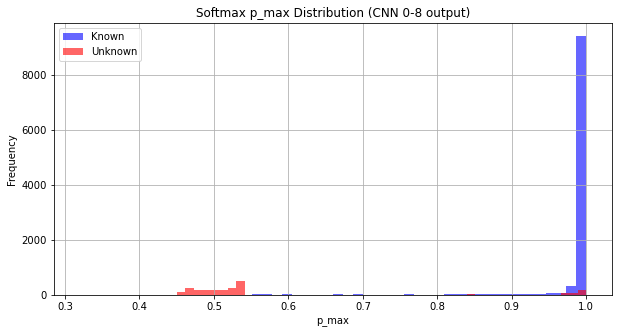

In [ ]:
# Step 1: Get CNN predictions
cnn_probs = model.predict(X_test_cnn)
cnn_preds = np.argmax(cnn_probs, axis=1)
p_max = np.max(cnn_probs, axis=1)

# Step 2: Separate based on true labels
true_labels = y_test

known_mask = true_labels != 10
unknown_mask = true_labels == 10

p_max_known = p_max[known_mask]
p_max_unknown = p_max[unknown_mask]
# Step 4: Print Stats
print(f"True known samples in test: {known_mask.sum()}")
print(f"True unknown samples in test: {unknown_mask.sum()}")

print(f"\n--- p_max Distribution ---")
print(f"Known class p_max: {p_max_known.mean():.4f} ± {p_max_known.std():.4f}")
print(f"Unknown class p_max: {p_max_unknown.mean():.4f} ± {p_max_unknown.std():.4f}")

# Step 5: Plot Distributions
plt.figure(figsize=(10,5))
plt.hist(p_max_known, bins=50, alpha=0.6, label='Known', color='blue')
plt.hist(p_max_unknown, bins=50, alpha=0.6, label='Unknown', color='red')
plt.title("Softmax p_max Distribution (CNN 0-8 output)")
plt.xlabel("p_max")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

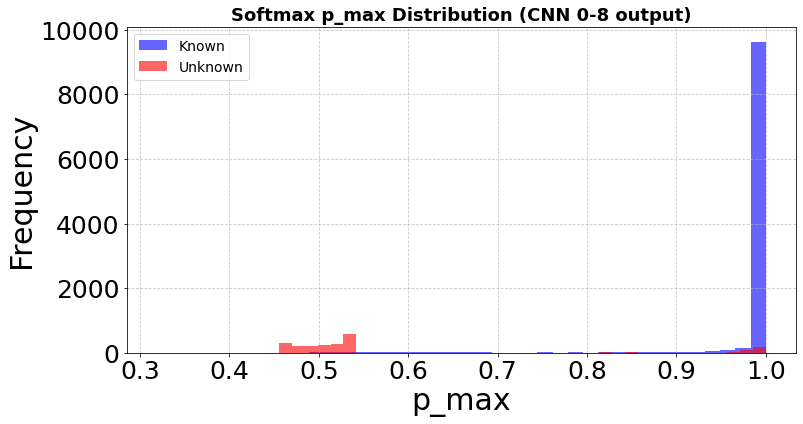

In [ ]:
# Step 5: Plot Distributions
plt.figure(figsize=(12,6))

# Increase histogram text size
plt.hist(p_max_known, bins=40, alpha=0.6, label='Known', color='blue')
plt.hist(p_max_unknown, bins=40, alpha=0.6, label='Unknown', color='red')

# Title and axis labels with bigger font
plt.title("Softmax p_max Distribution (CNN 0-8 output)", fontsize=18, fontweight='bold')
plt.xlabel("p_max", fontsize=30)
plt.ylabel("Frequency", fontsize=30)

# Bigger ticks (scale numbers on axes)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)

# Legend with bigger font
plt.legend(fontsize=14)

# Grid
plt.grid(True, linestyle="--", alpha=0.7)

plt.show()


In [ ]:
# Step 1: Get softmax predictions from CNN
cnn_probs = model.predict(X_test_cnn)  # shape
true_labels = y_test                   # shape

# Step 2: Save softmax outputs and true labels as npy
np.save("cnn_softmax_outputs.npy", cnn_probs)
np.save("true_labels.npy", true_labels)

print("Saved 'cnn_softmax_outputs.npy' (shape:", cnn_probs.shape, ")")
print("Saved 'true_labels.npy' (shape:", true_labels.shape, ")")


392/392 ━━━━━━━━━━━━━━━━━━━━ 0s 963us/step
Saved 'cnn_softmax_outputs.npy' (shape: (12519, 10) )
Saved 'true_labels.npy' (shape: (12519,) )


Known p1-p2: mean=0.9775, std=0.1052
Unknown p1-p2: mean=0.2835, std=0.3048


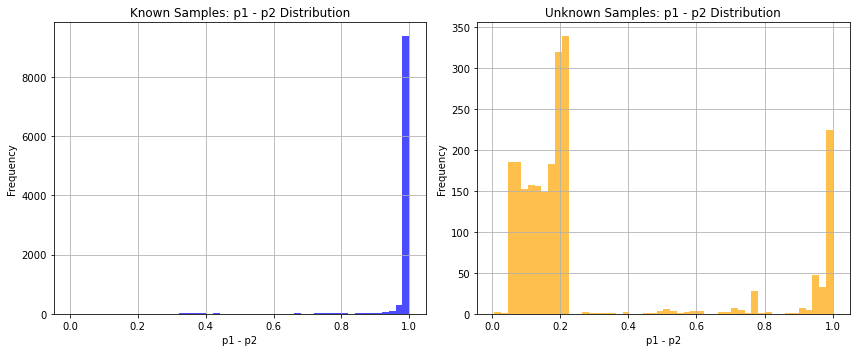

In [ ]:
# Load the saved softmax outputs and true labels
probs = np.load("cnn_softmax_outputs.npy")
true_labels = np.load("true_labels.npy")

# Compute p1 - p2 for each sample
sorted_probs = np.sort(probs, axis=1)
p1_minus_p2 = sorted_probs[:, -1] - sorted_probs[:, -2]

# Mask for known and unknown based on true labels
known_mask = true_labels != 10
unknown_mask = true_labels == 10

# Split p1-p2 for known and unknown
known_p1_p2_diff = p1_minus_p2[known_mask]
unknown_p1_p2_diff = p1_minus_p2[unknown_mask]

# Print summary statistics
print(f"Known p1-p2: mean={np.mean(known_p1_p2_diff):.4f}, std={np.std(known_p1_p2_diff):.4f}")
print(f"Unknown p1-p2: mean={np.mean(unknown_p1_p2_diff):.4f}, std={np.std(unknown_p1_p2_diff):.4f}")

# Plot distributions
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(known_p1_p2_diff, bins=50, color='blue', alpha=0.7)
plt.title("Known Samples: p1 - p2 Distribution")
plt.xlabel("p1 - p2")
plt.ylabel("Frequency")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.hist(unknown_p1_p2_diff, bins=50, color='orange', alpha=0.7)
plt.title("Unknown Samples: p1 - p2 Distribution")
plt.xlabel("p1 - p2")
plt.ylabel("Frequency")
plt.grid(True)

plt.tight_layout()
plt.show()


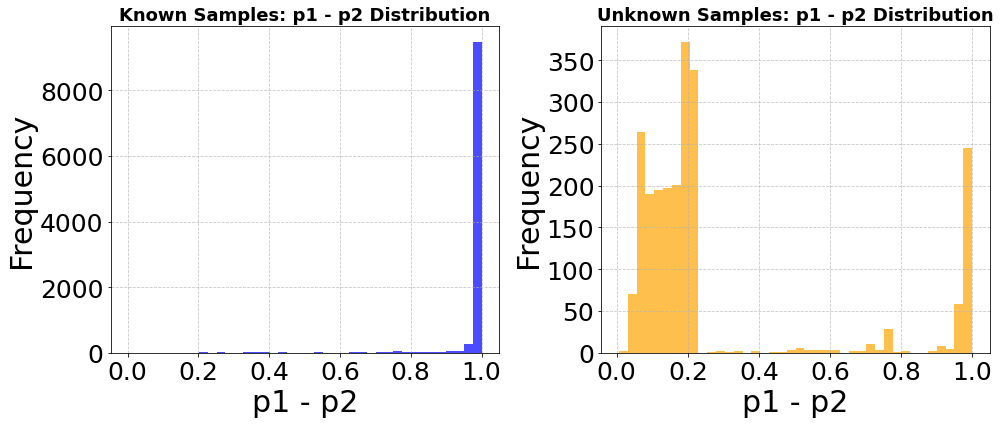

In [ ]:
# Plot distributions with larger fonts
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.hist(known_p1_p2_diff, bins=40, color='blue', alpha=0.7)
plt.title("Known Samples: p1 - p2 Distribution", fontsize=18, fontweight='bold')
plt.xlabel("p1 - p2", fontsize=30)
plt.ylabel("Frequency", fontsize=30)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.grid(True, linestyle="--", alpha=0.7)

plt.subplot(1, 2, 2)
plt.hist(unknown_p1_p2_diff, bins=40, color='orange', alpha=0.7)
plt.title("Unknown Samples: p1 - p2 Distribution", fontsize=18, fontweight='bold')
plt.xlabel("p1 - p2", fontsize=30)
plt.ylabel("Frequency", fontsize=30)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


In [ ]:
# Load saved outputs
softmax_outputs = np.load("cnn_softmax_outputs.npy")
true_labels = np.load("true_labels.npy")

# Get predicted labels (argmax)
predicted_labels = np.argmax(softmax_outputs, axis=1)

# Save as compressed .npz
np.savez("cnn_results_combined.npz",
         true_labels=true_labels,
         softmax_outputs=softmax_outputs,
         predicted_labels=predicted_labels)

print("Saved combined CNN results to 'cnn_results_combined.npz'")


Saved combined CNN results to 'cnn_results_combined.npz'


In [ ]:
# Verify saved file by loading it back
loaded_data = np.load("cnn_results_combined.npz")
print("Loaded arrays:", list(loaded_data.keys()))
print("True labels shape:", loaded_data['true_labels'].shape)
print("Softmax outputs shape:", loaded_data['softmax_outputs'].shape)
print("Predicted labels shape:", loaded_data['predicted_labels'].shape)
import numpy as np

# Load the .npz file
loaded_data = np.load("cnn_results_combined.npz")

# Get unique true labels
unique_true_labels = np.unique(loaded_data['true_labels'])
print("Unique true labels:", unique_true_labels)

# Get unique predicted labels
unique_predicted_labels = np.unique(loaded_data['predicted_labels'])
print("Unique predicted labels:", unique_predicted_labels)

Loaded arrays: ['true_labels', 'softmax_outputs', 'predicted_labels']
True labels shape: (12519,)
Softmax outputs shape: (12519, 10)
Predicted labels shape: (12519,)
Unique true labels: [ 0  1  2  3  4  5  6  7  8  9 10]
Unique predicted labels: [0 1 2 3 4 5 6 7 8 9]


322/322 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


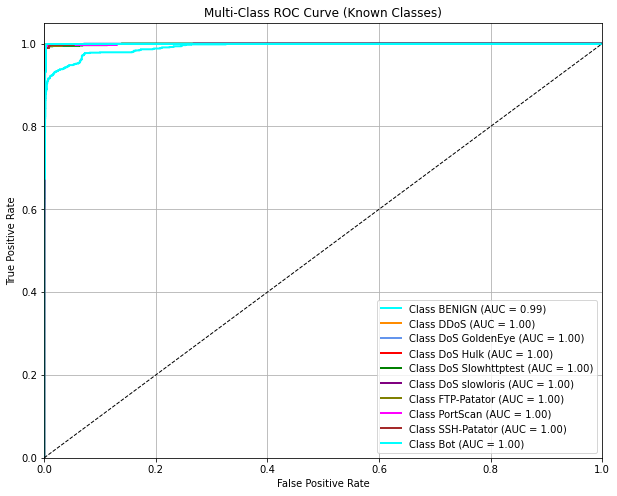

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from itertools import cycle


# Step 1: Get predictionss
y_score = model.predict(X_test_known)
y_true_bin = y_test_known_cat

n_classes = y_score.shape[1]
fpr = dict()
tpr = dict()
roc_auc = dict()

# Step 2: Compute ROC curve and ROC area for each class
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Step 3: Plot all ROC curves
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple', 'olive', 'magenta', 'brown'])
plt.figure(figsize=(10, 8))
for i, color in zip(range(n_classes), colors):
    class_name = le.inverse_transform([i])[0]  # if using LabelEncoder
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {class_name} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve (Known Classes)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


322/322 ━━━━━━━━━━━━━━━━━━━━ 0s 979us/step
Test Accuracy (Known classes only): 0.9732
Test F1 Score (Known classes only): 0.9726
Test Precision (Known classes only): 0.9738
Test Recall (Known classes only): 0.9732

Classification Report:
                  precision    recall  f1-score   support

          BENIGN       0.98      0.83      0.90      1100
            DDoS       0.97      1.00      0.99      1100
   DoS GoldenEye       0.99      0.98      0.99      1100
        DoS Hulk       0.97      1.00      0.98      1100
DoS Slowhttptest       0.99      0.98      0.99      1100
   DoS slowloris       0.97      0.99      0.98      1100
     FTP-Patator       0.99      0.99      0.99      1100
        PortScan       0.97      0.99      0.98      1099
     SSH-Patator       0.96      0.99      0.98      1100
             Bot       0.88      1.00      0.94       393

        accuracy                           0.97     10292
       macro avg       0.97      0.97      0.97     10292
    we

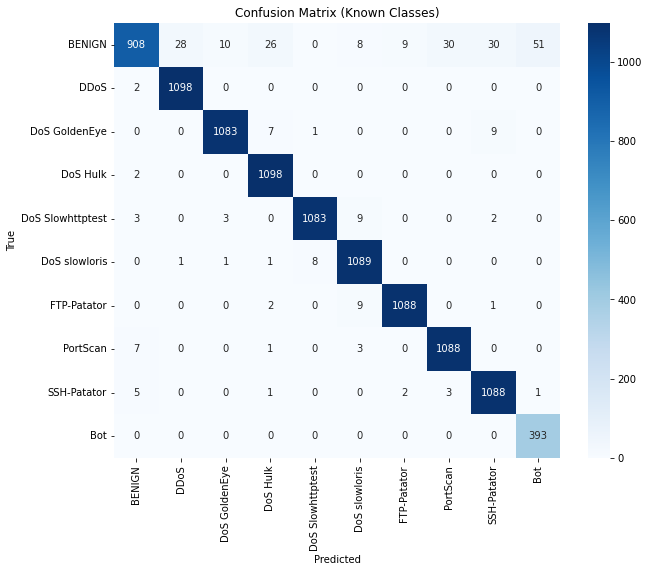

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

# Step 13: Test metrics (known classes only)
known_mask = y_test != le.transform(['Unknown'])[0]
X_test_known = X_test_cnn[known_mask]
y_test_known_cat = y_test_cat[known_mask]

# Predictions
test_pred_known = model.predict(X_test_known)
test_pred_classes = np.argmax(test_pred_known, axis=1)
test_true_classes = np.argmax(y_test_known_cat, axis=1)

# Metrics
test_acc = accuracy_score(test_true_classes, test_pred_classes)
test_f1 = f1_score(test_true_classes, test_pred_classes, average='weighted')
test_precision = precision_score(test_true_classes, test_pred_classes, average='weighted', zero_division=0)
test_recall = recall_score(test_true_classes, test_pred_classes, average='weighted')

# Output metrics
print(f"Test Accuracy (Known classes only): {test_acc:.4f}")
print(f"Test F1 Score (Known classes only): {test_f1:.4f}")
print(f"Test Precision (Known classes only): {test_precision:.4f}")
print(f"Test Recall (Known classes only): {test_recall:.4f}")

# Classification report
target_names = le.inverse_transform(np.unique(test_true_classes))
print("\nClassification Report:")
print(classification_report(test_true_classes, test_pred_classes, target_names=target_names))

# Optional: Confusion matrix
cm = confusion_matrix(test_true_classes, test_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Known Classes)')
plt.show()


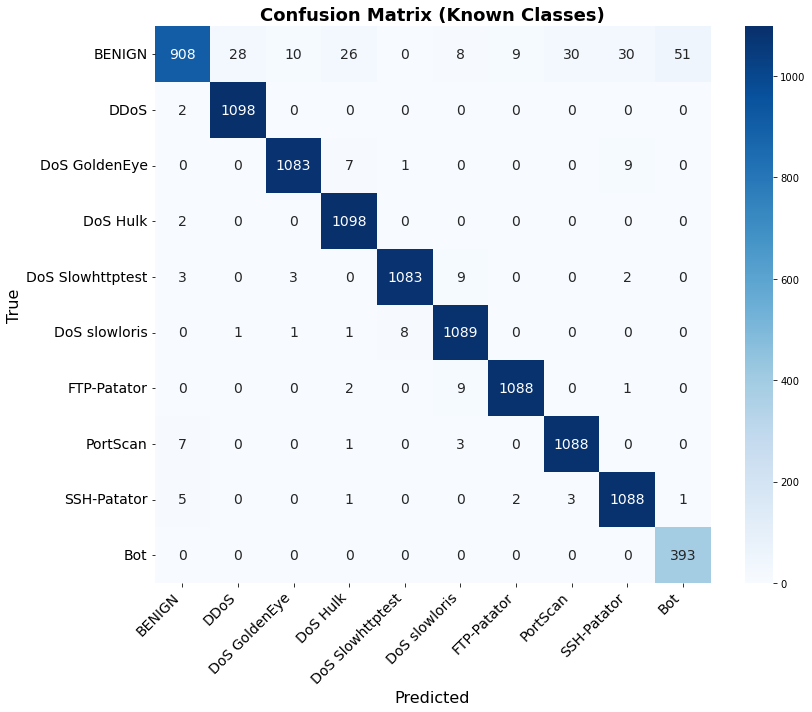

In [ ]:
# Confusion matrix with improved readability
cm = confusion_matrix(test_true_classes, test_pred_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names,
    annot_kws={"size": 14}   # increase numbers inside the boxes
)

# Bigger labels and title
plt.xlabel('Predicted', fontsize=16)
plt.ylabel('True', fontsize=16)
plt.title('Confusion Matrix (Known Classes)', fontsize=18, fontweight='bold')

# Tick labels bigger
plt.xticks(fontsize=14, rotation=45, ha="right")
plt.yticks(fontsize=14, rotation=0)

plt.tight_layout()
plt.show()


In [ ]:
import time
import numpy as np

# Ensure numpy array
if hasattr(X_test, "values"):
    X_test_array = X_test.values
else:
    X_test_array = np.array(X_test)

# Reshape if model expects (features, 1)
try:
    expected_shape = model.input_shape  # e.g., (None, 68, 1)
except:
    expected_shape = None

needs_reshape = False
if expected_shape and len(expected_shape) == 3 and expected_shape[-1] == 1:
    needs_reshape = True

batch_size = 64
n_samples = len(X_test_array)
n_batches = (n_samples + batch_size - 1) // batch_size

batch_times = []

for i in range(n_batches):
    batch = X_test_array[i*batch_size : (i+1)*batch_size]

    # If needed, reshape to (batch, features, 1)
    if needs_reshape:
        batch = batch.reshape(batch.shape[0], batch.shape[1], 1)

    start = time.time()
    _ = model.predict(batch, verbose=0)
    end = time.time()

    batch_times.append(end - start)

total_time = np.sum(batch_times)
avg_batch_time = total_time / n_batches
avg_sample_time = total_time / n_samples

print(f"Total inference time: {total_time:.4f} sec")
print(f"Average time per batch: {avg_batch_time:.6f} sec")
print(f"Average time per sample: {avg_sample_time*1000:.6f} ms")


Total inference time: 6.5290 sec
Average time per batch: 0.033311 sec
Average time per sample: 0.521526 ms


In [ ]:
#Model Review:

# 1. Close Train vs Validation Accuracy
#    - Training accuracy: ~96.4%
#    - Validation accuracy: ~97.18%
#    - Indicates stable learning and no overfitting.

# 2. Close Train vs Validation F1 Score
#    - Training F1 score: 0.9713
#    - Validation F1 score: 0.9685
#    - Suggests balanced class-wise performance across sets.

# 3. High Test Performance on Unseen Data
#    - Test accuracy: 0.9693
#    - Test F1 score: 0.9685
#    - Confirms generalization beyond the training data.

# 4. Validation Loss Lower Than Training Loss
#    - Training loss: ~0.61
#    - Validation loss: ~0.49
#    - Expected behavior due to dropout/batchnorm being inactive during validation.

# 5. ROC-AUC Curve Indicates Strong Class Separation
#    - AUC = 1.00 for all classes except BENIGN (0.98)
#    - Shows excellent model discrimination ability.

# 6. No Signs of Underfitting
#    - High training accuracy and F1 score
#    - Confirms the model has learned the data patterns effectively.

# 7. Loss Curves Have Converged
#    - Loss stabilizes in final epochs without increase
#  -  Suggests the model has reached a good learning plateau.


'→'